# Classification DPE — Performant / Passable / Energivore
## Pipeline Arbre de Decision et Random Forest

**Entree :** `data_for_processing_final.xlsx` — la colonne `etiquette_dpe` contient directement
les 3 groupes cibles. Variables qualitatives en texte brut (pas de colonnes pre-encodees `_enc`
dans ce fichier).

**Objectif :** entrainer et comparer un arbre de decision (CART) seul et une foret aleatoire
(Random Forest, bagging d'arbres), afin d'illustrer concretement l'apport de l'agregation de modeles (apprentissage d'ensemble)
par rapport a un arbre unique.

**Specificites de l'arbre de decision et du Random Forest par rapport aux modeles precedents :**
- Pas de sensibilite a l'echelle des variables (contrairement a la regression logistique et au
  SVM) : un arbre ne fait que des comparaisons de seuils, pas de calculs de distance.
- L'arbre de decision seul est notoirement instable (forte variance) : une petite modification
  des donnees d'entrainement peut produire un arbre tres different.
- Le Random Forest reduit cette variance par bagging (agregation de plusieurs arbres entraines
  sur des echantillons bootstrap, avec tirage aleatoire des variables a chaque noeud), au prix
  d'un biais leg erement plus eleve et d'une perte d'interpretabilite directe.
- Notion d'importance des variables (basee sur la reduction de l'impurete de Gini), disponible
  nativement pour les deux modeles.
- Notion de score Out-of-Bag (OOB), propre au bagging : score de validation calcule gratuitement
  a partir des observations non tirees dans chaque echantillon bootstrap.
- Cout algorithmique faible (contrairement au SVM a noyau) : pas besoin de sous-echantillonner
  pour entrainer sur l'integralite du train set.

**Pas de calibration** des probabilites dans ce notebook (volontairement laissee de cote).

**Plan du notebook :**
1. Imports et configuration
2. Chargement des donnees
3. Pretraitement
4. Split train / test
5. Pipeline et preprocesseur partage
6. Arbre de decision (CART)
   - 6.1 Optimisation des hyperparametres (Optuna)
   - 6.2 Entrainement final
   - 6.3 Visualisation de l'arbre
7. Random Forest
   - 7.1 Optimisation des hyperparametres (Optuna)
   - 7.2 Entrainement final
   - 7.3 Score Out-of-Bag (OOB)
   - 7.4 Effet du nombre d'arbres (n_estimators)
8. Comparaison Arbre vs Random Forest
9. Evaluation des modeles
   - 9.1 Courbes d'apprentissage (train vs validation)
   - 9.2 Diagnostic de surapprentissage (accuracy)
   - 9.3 Matrice de confusion
   - 9.4 Rapport de classification (precision / rappel / F1 par classe)
   - 9.5 Courbes ROC et Precision-Rappel (one-vs-rest)
10. Diagnostics propres aux arbres
   - 10.1 Importance des variables (Gini)
   - 10.2 Courbe de validation sur la profondeur (max_depth)
11. Conclusion


## 1. Imports et configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.preprocessing import label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    learning_curve, validation_curve
)
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve
)
from category_encoders import TargetEncoder

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
%matplotlib inline


####################################### A PARAMETRER ################################

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Les 3 groupes metier, directement disponibles dans la colonne cible
TARGET = "etiquette_dpe"
GROUPS = ["Performant", "Passable", "Energivore"]

GROUP_COLORS = {
    "Performant": "#00923F",
    "Passable":   "#F2C12B",
    "Energivore": "#E6442E",
}

N_TRIALS = 25  # nombre d'essais Optuna par modele

print("Imports OK")
print(f"  Cible : '{TARGET}' -> {GROUPS}")


Imports OK
  Cible : 'etiquette_dpe' -> ['Performant', 'Passable', 'Energivore']


## 2. Chargement des donnees

In [ ]:
FILE_PATH = "resources/data_for_processing_final.xlsx"

df = pd.read_excel(FILE_PATH)
print(f"Dataset : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"Valeurs manquantes totales : {df.isnull().sum().sum()}")

na_par_colonne = df.isnull().sum()
na_par_colonne = na_par_colonne[na_par_colonne > 0]
if len(na_par_colonne) > 0:
    print("\nColonnes concernees par des valeurs manquantes :")
    print(na_par_colonne)

vals = df[TARGET].unique()
print(f"\nValeurs uniques de '{TARGET}' : {sorted(vals)}")
print("Cible validee, les 3 groupes attendus sont presents")

print("\nDistribution de la cible :")
vc = df[TARGET].value_counts().reindex(GROUPS)
for grp, cnt in vc.items():
    pct = cnt / len(df) * 100
    bar = "#" * int(pct / 2)
    print(f"  {grp:<12} {cnt:6,}  ({pct:5.1f}%)  {bar}")

print(f"\nRatio de desequilibre : {vc.max() / vc.min():.1f}:1")


Dataset : 55,357 lignes x 25 colonnes
Valeurs manquantes totales : 9

Colonnes concernees par des valeurs manquantes :
configuration_installation_chauffage_n1    9
dtype: int64

Valeurs uniques de 'etiquette_dpe' : ['Energivore', 'Passable', 'Performant']
Cible validee, les 3 groupes attendus sont presents

Distribution de la cible :
  Performant    2,303  (  4.2%)  ##
  Passable     39,557  ( 71.5%)  ###################################
  Energivore   13,497  ( 24.4%)  ############

Ratio de desequilibre : 17.2:1


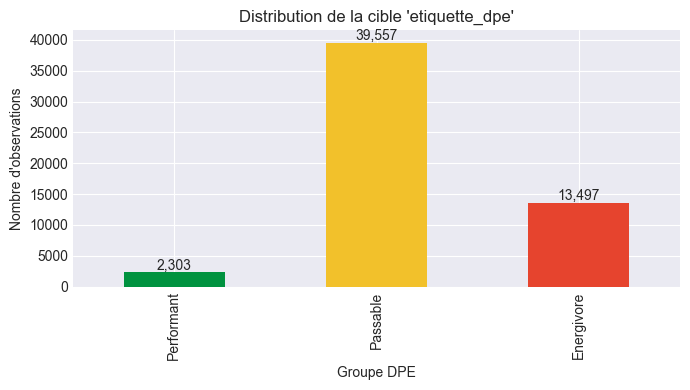

In [3]:
'''
Visualisation de la distribution de la cible. Sert a illustrer le desequilibre des
classes, deja constate ci-dessus, qui justifiera plus loin l'usage de poids de
classe pour l'arbre et la foret plutot que la seule exactitude comme critere
d'evaluation.
'''
fig, ax = plt.subplots(figsize=(7, 4))
vc.plot(kind="bar", color=[GROUP_COLORS[g] for g in vc.index], ax=ax)
ax.set_title("Distribution de la cible 'etiquette_dpe'")
ax.set_xlabel("Groupe DPE")
ax.set_ylabel("Nombre d'observations")
for i, v in enumerate(vc.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


## 3. Pretraitement des donnees


In [ ]:
def suppress_quasi_const(df):
    '''
    Supprime les colonnes quasi-constantes, c'est a dire les colonnes pour lesquelles
    une seule valeur represente plus de 95% des observations.

    Justification : une telle colonne n'apporte presque pas de variabilite au modele
    et se comporte essentiellement comme du bruit plutot que comme un signal utile.
    '''
    quasi_cst = [
        c for c in df.columns
        if c != TARGET
        and df[c].value_counts(normalize=True).iloc[0] > 0.95
    ]

    if quasi_cst:
        print(f"{'=' * 80}")
        print(f"Colonnes quasi-constantes supprimees ({len(quasi_cst)}) :")
        print(f"{'=' * 80}")
        for c in quasi_cst:
            top_val = df[c].value_counts(normalize=True).iloc[0]
            top_lab = df[c].value_counts().index[0]
            print(f"  {c:<50}  '{top_lab}' ({top_val:.1%})")
        df = df.drop(columns=quasi_cst)
    else:
        print(f"{'=' * 80}")
        print("Aucune colonne quasi-constante")
        print(f"{'=' * 80}")
    return df


def capping_outlier(df):
    '''
    Traitement des valeurs extremes :
    - hauteur_sous_plafond : ecretee (clip) a 6 metres, valeur jugee physiquement
      raisonnable pour un logement, au dela on considere une erreur de saisie.
    - colonnes a forte proportion de zeros (stockage ECS, production PV) : transformation
      log1p pour reduire l'asymetrie de la distribution sans perdre l'information des zeros.
    '''
    if "hauteur_sous_plafond" in df.columns:
        n = (df["hauteur_sous_plafond"] > 6.0).sum()
        df["hauteur_sous_plafond"] = df["hauteur_sous_plafond"].clip(upper=6.0)
        print(f"hauteur_sous_plafond clippee a 6m ({n} valeurs corrigees)")

    for col in ["volume_stockage_generateur_n1_ecs_n1",
                "production_electricite_pv_kwhep_par_an"]:
        if col in df.columns:
            df[col] = np.log1p(df[col])
            print(f"{col} -> log1p")

    print(f"\n{'=' * 80}")
    print(f"Dataset apres nettoyage : {df.shape[0]:,} x {df.shape[1]}")
    print(f"{'=' * 80}")
    return df

def encoding_ordinal(df):
    ordinal_vars = {
        'qualite_isolation_enveloppe':   ['insuffisante', 'moyenne', 'bonne', 'très bonne'],
        'qualite_isolation_murs':        ['insuffisante', 'moyenne', 'bonne', 'très bonne'],
        'qualite_isolation_menuiseries':  ['insuffisante', 'moyenne', 'bonne', 'très bonne'],
        'qualite_isolation_plancher_bas': ['insuffisante', 'moyenne', 'bonne', 'très bonne'],
        'classe_inertie_batiment':        ['Légère', 'Moyenne', 'Lourde', 'Très lourde'],
        'periode_construction':           ['ancien', 'transition', 'moderne', 'recent', 'tres_recent'],
    }

    for col, order in ordinal_vars.items():
        if col not in df.columns:
            continue
        vals_in_data = set(df[col].dropna().unique())
        vals_in_order = set(order)
        unexpected = vals_in_data - vals_in_order
        if unexpected:
            print(f"⚠️  {col}: valeurs non prévues dans l'ordre → {unexpected}")
            for uv in unexpected:
                order.append(uv)

        mapping = {v: i for i, v in enumerate(order)}
        df[col + '_enc'] = df[col].map(mapping)
        n_nan = df[col + '_enc'].isnull().sum()
        print(f"{col} → encodé ({len(order)} niveaux, {n_nan} NaN)")

    # Suppression des colonnes d'origine, une fois encodées
    df = df.drop(columns=list(ordinal_vars.keys()))
    return df   # <-- la ligne qui manquait




In [ ]:
def classe_features(df):
    '''
    Classe les colonnes du dataframe en 4 groupes selon le traitement qu'elles
    recevront dans le preprocesseur :
    - ordinal_enc_cols  : deja encodees en amont (suffixe '_enc'), passees telles quelles.
    - binary_cols       : variables binaires, passees telles quelles.
    - quant_cols        : variables numeriques continues, a mettre a l'echelle.
    - qual_cols         : variables qualitatives nominales restantes, a encoder (TargetEncoder).
    '''
    ordinal_enc_cols = [c for c in df.columns if c.endswith("_enc")]

    binary_cols = [c for c in ["ventilation_posterieure_2012"] if c in df.columns]

    base_num = ["hauteur_sous_plafond", "volume_stockage_generateur_n1_ecs_n1",
                "production_electricite_pv_kwhep_par_an"]
    quant_cols = [c for c in base_num if c in df.columns]

    exclude = [TARGET] + ordinal_enc_cols + binary_cols + quant_cols
    qual_cols = [
        c for c in df.columns
        if c not in exclude
        and (df[c].dtype == object or str(df[c].dtype) == "str")
    ]

    passthrough_cols = ordinal_enc_cols + binary_cols
    all_features = quant_cols + qual_cols + passthrough_cols

    print(f"\n{'=' * 40} Features pour le modele {'=' * 40}")
    print(f"Features totales : {len(all_features)}")
    print(f"  Numeriques   ({len(quant_cols)}) : {quant_cols}")
    print(f"  Qualitatives ({len(qual_cols)})")
    print(f"  Passthrough  ({len(passthrough_cols)})")
    print(f"{'=' * 80}")

    return all_features, quant_cols, qual_cols, passthrough_cols


def preprocessing(df):
    '''Enchaine les 3 etapes de nettoyage / classement des colonnes.'''
    df_suppr_quasi_const = suppress_quasi_const(df)
    df_process = capping_outlier(df_suppr_quasi_const)
    df_process_ordinal = encoding_ordinal(df_process)
    all_features, quant_cols, qual_cols, passthrough_cols = classe_features(df_process_ordinal)
    return df_process_ordinal, all_features, quant_cols, qual_cols, passthrough_cols


In [ ]:
df_data, all_features, quant_cols, qual_cols, passthrough_cols = preprocessing(df)


Lignes supprimees pour valeurs manquantes : 9
Dataset restant : 55,348 lignes
Colonnes quasi-constantes supprimees (6) :
  zone_climatique                                     'H1a' (99.9%)
  classe_altitude                                     'inférieur à 400m' (100.0%)
  configuration_installation_chauffage_n1             'standard' (99.7%)
  configuration_installation_ecs_n1                   'Un seul système d'ECS sans solaire' (98.7%)
  type_installation_solaire_n1                        'Non affecté' (99.3%)
  production_electricite_pv_kwhep_par_an              '0.0' (98.9%)
hauteur_sous_plafond clippee a 6m (20 valeurs corrigees)
volume_stockage_generateur_n1_ecs_n1 -> log1p

Dataset apres nettoyage : 55,348 x 19

======================================== Features pour le modele ========================================
Features totales : 18
  Numeriques   (2) : ['hauteur_sous_plafond', 'volume_stockage_generateur_n1_ecs_n1']
  Qualitatives (15)
  Passthrough  (1)


## 4. Split train / test

In [7]:
'''
Separation stratifiee train/test (80/20). La stratification garantit que la
proportion des 3 groupes DPE reste identique entre train et test, ce qui est
indispensable ici puisque les classes sont fortement desequilibrees (cf. section 2).
'''
X = df_data[all_features].copy()
y = df_data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Train : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}")
print()
print("Distribution train :")
for grp in GROUPS:
    cnt = (y_train == grp).sum()
    pct = cnt / len(y_train) * 100
    print(f"  {grp:<12} {cnt:6,}  ({pct:.1f}%)")

print("\nVerification de la stratification :")
for grp in GROUPS:
    p_tr = (y_train == grp).mean() * 100
    p_te = (y_test == grp).mean() * 100
    delta = abs(p_tr - p_te)
    flag = "OK" if delta < 1.0 else "ATTENTION"
    print(f"  {grp:<12} train={p_tr:.1f}%  test={p_te:.1f}%  delta={delta:.2f}%  {flag}")


Train : 44,278  |  Test : 11,070

Distribution train :
  Performant    1,841  (4.2%)
  Passable     31,644  (71.5%)
  Energivore   10,793  (24.4%)

Verification de la stratification :
  Performant   train=4.2%  test=4.2%  delta=0.01%  OK
  Passable     train=71.5%  test=71.5%  delta=0.00%  OK
  Energivore   train=24.4%  test=24.4%  delta=0.00%  OK


**Pas de sous-echantillonnage necessaire ici.** Contrairement au SVM a noyau, l'arbre de
decision et le Random Forest passent bien a l'echelle : toutes les etapes de ce notebook
(recherche Optuna, courbes d'apprentissage, validation_curve) sont effectuees directement sur
l'integralite de `X_train` / `y_train`.

## 5. Pipeline et preprocesseur partage

Le meme `make_preprocessor()` est utilise pour l'arbre de decision et le Random Forest, afin
de garantir une comparaison strictement equitable.

In [8]:
def make_preprocessor():
    '''
    Construit le ColumnTransformer partage par les deux modeles de ce notebook :
    - num  : variables numeriques continues, passees sans mise a l'echelle (un arbre n'est
      pas sensible a l'echelle des variables, contrairement a la regression logistique ou
      au SVM).
    - cat  : TargetEncoder sur les variables qualitatives. Remplace chaque modalite par
      une statistique liee a la cible plutot que de creer une colonne par modalite.
    - pass : variables deja encodees ou binaires, passees sans transformation.
    '''
    cat_tr = TargetEncoder(smoothing=3.0, min_samples_leaf=50)

    transformers = [("num", "passthrough", quant_cols)]
    if qual_cols:
        transformers.append(("cat", cat_tr, qual_cols))
    if passthrough_cols:
        transformers.append(("pass", "passthrough", passthrough_cols))

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )


def make_model_pipeline(estimator):
    '''Encapsule un estimateur quelconque dans le pipeline de preprocessing partage.'''
    return Pipeline([
        ("pre", make_preprocessor()),
        ("clf", estimator),
    ])


print("make_preprocessor() et make_model_pipeline() definis")


make_preprocessor() et make_model_pipeline() definis


In [9]:
def make_callback(n_trials, label="Optuna"):
    '''
    Construit un callback Optuna affichant la progression de l'optimisation :
    barre de progression, score du dernier essai, meilleur score trouve, temps
    ecoule et temps restant estime (ETA).
    '''
    scores = []
    t0 = [time.time()]

    def cb(study, trial):
        if trial.value is None:
            return
        scores.append(trial.value)
        best = study.best_value
        done = len(scores)
        elapsed = time.time() - t0[0]
        eta = (elapsed / done) * (n_trials - done)
        pct = done / n_trials
        bar = "#" * int(30 * pct) + "-" * (30 - int(30 * pct))

        print(f"\r[{label}] [{bar}] {done:>3}/{n_trials} ({pct * 100:5.1f}%)  "
              f"f1_macro={trial.value:.5f}  meilleur={best:.5f}  "
              f"ecoule={elapsed / 60:.1f}min  eta={eta / 60:.1f}min", end="")

        if done == n_trials:
            print(f"\nTermine. Meilleur f1_macro CV : {best:.5f}")
    return cb


trained_models = {}


## 6. Arbre de decision (CART)

L'arbre de decision sert ici de modele de reference avant le Random Forest : il permet
d'illustrer concretement, en section 8, l'apport de l'agregation par bagging. Un arbre de
decision seul est notoirement instable (forte variance) : une petite modification des
donnees d'entrainement peut produire un arbre tres different (cf. cours, chapitre 9).

### 6.1 Optimisation des hyperparametres (Optuna)

Hyperparametres optimises :
- `max_depth` : profondeur maximale de l'arbre. Un arbre trop profond memorise les donnees
  d'entrainement (sur-apprentissage), un arbre trop peu profond ne capture pas la structure
  des donnees (sous-apprentissage).
- `min_samples_leaf` : nombre minimal d'observations dans une feuille. Une valeur trop faible
  autorise des feuilles tres specifiques (sur-apprentissage).
- `min_samples_split` : nombre minimal d'observations pour autoriser un nouveau decoupage.
- `class_weight` (poids de classe) : optimise conjointement, car le jeu de donnees est
  fortement desequilibre.

In [10]:
def objective_tree(trial):
    '''
    Fonction objectif Optuna pour l'arbre de decision.
    '''
    weight_perf = trial.suggest_int("weight_Performant", 1, 25)
    weight_ener = trial.suggest_int("weight_Energivore", 1, 15)
    class_weight = {
        "Performant": weight_perf,
        "Passable":   1,
        "Energivore": weight_ener,
    }

    params = dict(
        max_depth=trial.suggest_int("max_depth", 3, 30),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 100),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 100),
    )
    pipeline = make_model_pipeline(
        DecisionTreeClassifier(
            **params,
            class_weight=class_weight,
            random_state=RANDOM_STATE,
        )
    )
    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv5, scoring="f1_macro", n_jobs=-1, error_score=0.0
    )
    return scores.mean()


study_tree = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name="dpe_decision_tree",
)
study_tree.optimize(
    objective_tree, n_trials=N_TRIALS,
    callbacks=[make_callback(N_TRIALS, "Arbre de decision")]
)


[Arbre de decision] [##############################]  25/25 (100.0%)  f1_macro=0.70127  meilleur=0.75194  ecoule=1.0min  eta=0.0min
Termine. Meilleur f1_macro CV : 0.75194


### 6.2 Entrainement final

In [11]:
'''
Entrainement final de l'arbre de decision avec les meilleurs hyperparametres trouves
par Optuna, sur l'integralite du train set.
'''
print("Entrainement final - Arbre de decision...")
t0 = time.time()

tree_best_params = study_tree.best_params.copy()
weight_perf = tree_best_params.pop("weight_Performant")
weight_ener = tree_best_params.pop("weight_Energivore")
TREE_CLASS_WEIGHT = {
    "Performant": weight_perf,
    "Passable":   1,
    "Energivore": weight_ener,
}

model_tree = make_model_pipeline(
    DecisionTreeClassifier(
        **tree_best_params,
        class_weight=TREE_CLASS_WEIGHT,
        random_state=RANDOM_STATE,
    )
)
model_tree.fit(X_train, y_train)
print(f"Entraine en {time.time() - t0:.1f}s")
print(f"Meilleur f1_macro CV : {study_tree.best_value:.5f}")
print(f"Poids retenus -> Performant:{weight_perf}  Passable:1  Energivore:{weight_ener}")
print(f"Hyperparametres retenus : {tree_best_params}")

trained_models["Arbre de decision"] = model_tree


Entrainement final - Arbre de decision...
Entraine en 2.0s
Meilleur f1_macro CV : 0.75194
Poids retenus -> Performant:2  Passable:1  Energivore:1
Hyperparametres retenus : {'max_depth': 30, 'min_samples_leaf': 20, 'min_samples_split': 71}


### 6.3 Visualisation de l'arbre

L'arbre de decision optimal peut etre trop profond pour etre lisible dans son integralite.
On affiche ici les 3 premiers niveaux seulement (`max_depth=3` a l'affichage), pour illustrer
la logique de decoupage successive sans saturer la figure. C'est une vue partielle : l'arbre
reellement utilise pour les predictions est celui entraine en section 6.2, avec sa profondeur
complete.

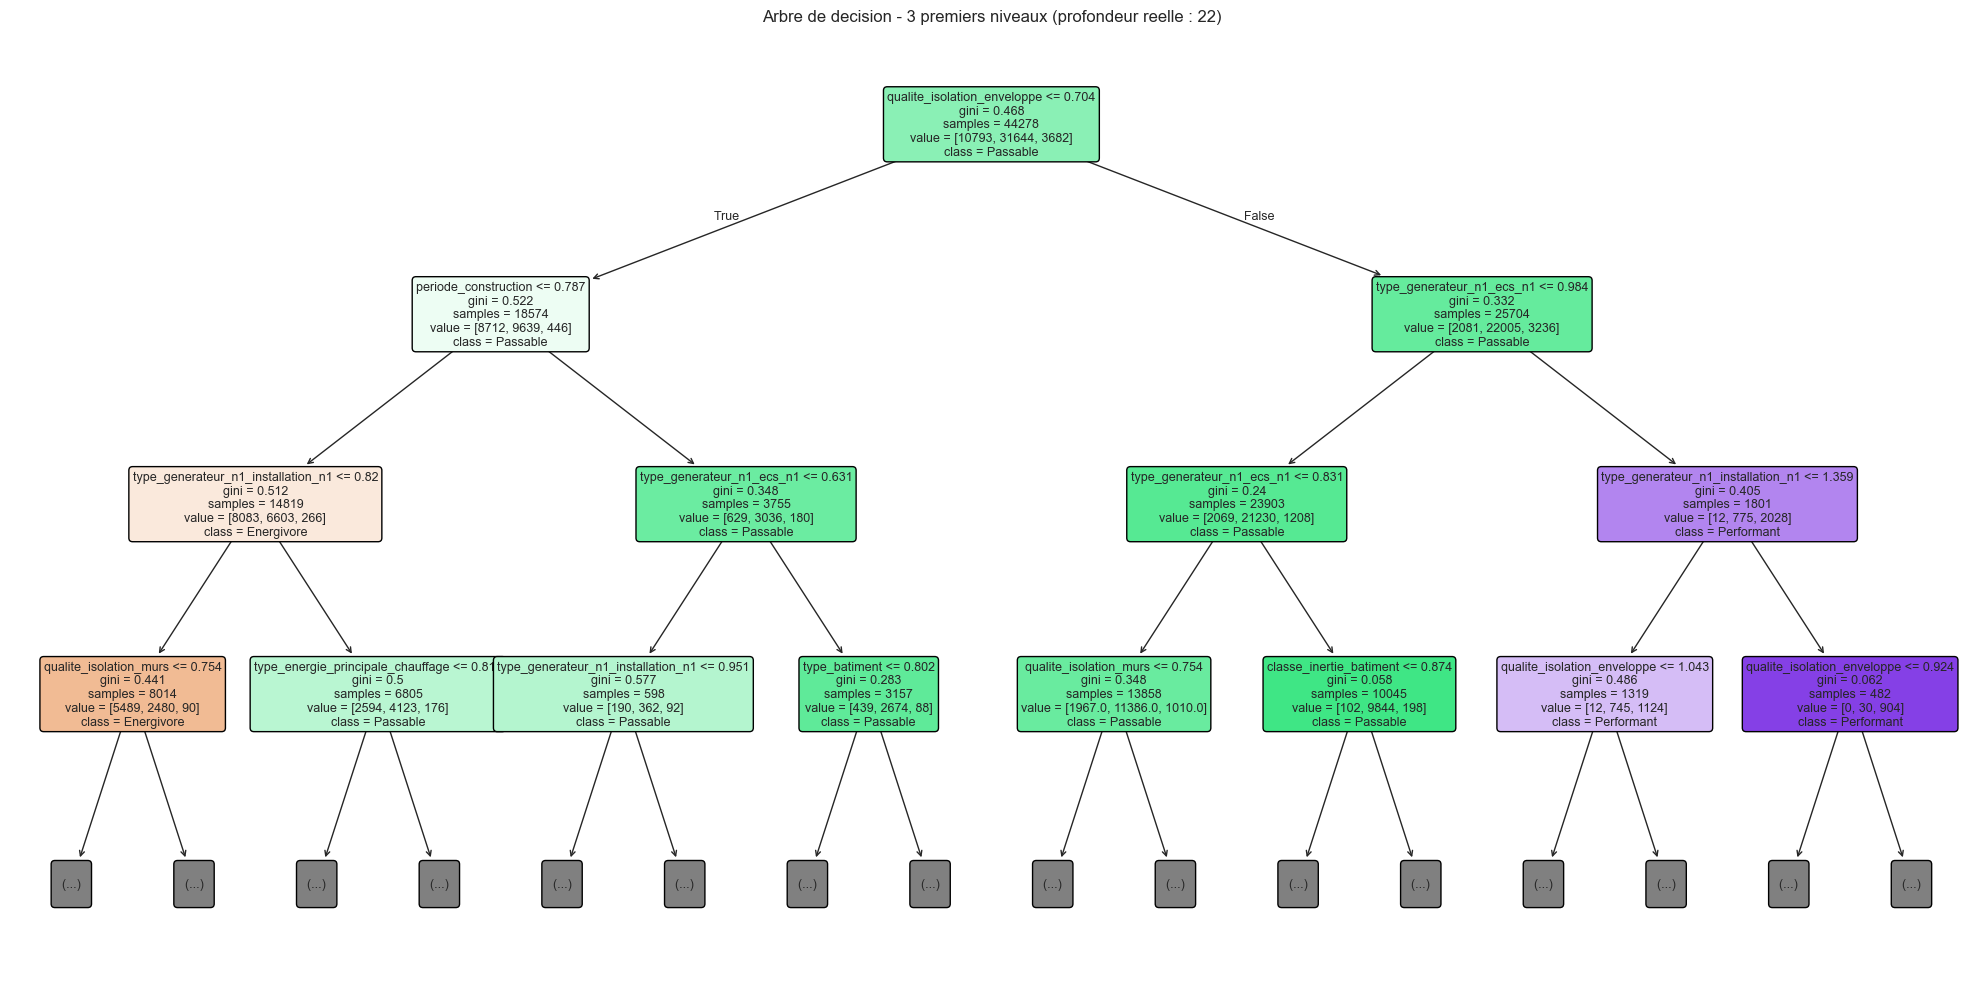

In [12]:
'''
Visualise les 3 premiers niveaux de l'arbre de decision entraine. plot_tree affiche, pour
chaque noeud, la variable et le seuil de decoupage, l'impurete de Gini, le nombre
d'observations et la classe majoritaire.
'''
feature_names = model_tree.named_steps["pre"].get_feature_names_out()
clf_tree = model_tree.named_steps["clf"]

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    clf_tree,
    max_depth=3,
    feature_names=feature_names,
    class_names=clf_tree.classes_,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
)
ax.set_title("Arbre de decision - 3 premiers niveaux (profondeur reelle : "
             f"{clf_tree.get_depth()})")
plt.tight_layout()
plt.show()


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

On voit que le premier split se fait sur `qualite_isolation_enveloppe`, ce qui parait logique
vu que c'est la variable la plus directement liee a la performance energetique d'un logement.
On remarque aussi que l'arbre est tres profond (22 niveaux reels, alors qu'Optuna avait
autorise jusqu'a 30), ce qui colle bien avec l'instabilite des arbres de decision mentionnee
dans le cours : il a besoin de beaucoup de decoupages successifs pour bien separer les classes.


## 7. Random Forest

Le Random Forest entraine de nombreux arbres de decision sur des echantillons bootstrap
differents (bagging), avec un tirage aleatoire des variables candidates a chaque noeud. Cette
double source d'alea accroit la diversite des arbres, ce qui reduit la variance de l'ensemble
par rapport a un arbre unique, au prix d'un leger biais supplementaire (cf. cours, chapitre 9).

### 7.1 Optimisation des hyperparametres (Optuna)

Hyperparametres optimises (cf. cours, page 17) :
- `n_estimators` : nombre d'arbres dans la foret.
- `max_depth` : profondeur maximale de chaque arbre.
- `max_features` : nombre de variables tirees aleatoirement a chaque noeud (le cours indique
  une valeur usuelle proche de la racine carree du nombre total de variables en classification).
- `min_samples_leaf` : nombre minimal d'observations dans une feuille.
- `class_weight` : poids de classe, optimise conjointement.

In [13]:
def objective_rf(trial):
    '''
    Fonction objectif Optuna pour le Random Forest.
    '''
    weight_perf = trial.suggest_int("weight_Performant", 1, 25)
    weight_ener = trial.suggest_int("weight_Energivore", 1, 15)
    class_weight = {
        "Performant": weight_perf,
        "Passable":   1,
        "Energivore": weight_ener,
    }

    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 500, step=50),
        max_depth=trial.suggest_int("max_depth", 5, 30),
        max_features=trial.suggest_float("max_features", 0.1, 1.0),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 50),
    )
    pipeline = make_model_pipeline(
        RandomForestClassifier(
            **params,
            class_weight=class_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    )
    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv5, scoring="f1_macro", n_jobs=-1, error_score=0.0
    )
    return scores.mean()


study_rf = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name="dpe_random_forest",
)
study_rf.optimize(
    objective_rf, n_trials=N_TRIALS,
    callbacks=[make_callback(N_TRIALS, "Random Forest")]
)


[Random Forest] [##############################]  25/25 (100.0%)  f1_macro=0.73660  meilleur=0.77186  ecoule=3.1min  eta=0.0min
Termine. Meilleur f1_macro CV : 0.77186


### 7.2 Entrainement final

In [14]:
'''
Entrainement final du Random Forest avec les meilleurs hyperparametres trouves par
Optuna, sur l'integralite du train set. oob_score=True active le calcul du score
Out-of-Bag (section 7.3), sans cout supplementaire notable.
'''
print("Entrainement final - Random Forest...")
t0 = time.time()

rf_best_params = study_rf.best_params.copy()
weight_perf = rf_best_params.pop("weight_Performant")
weight_ener = rf_best_params.pop("weight_Energivore")
RF_CLASS_WEIGHT = {
    "Performant": weight_perf,
    "Passable":   1,
    "Energivore": weight_ener,
}

model_rf = make_model_pipeline(
    RandomForestClassifier(
        **rf_best_params,
        class_weight=RF_CLASS_WEIGHT,
        oob_score=True,
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
)
model_rf.fit(X_train, y_train)
print(f"Entraine en {time.time() - t0:.1f}s")
print(f"Meilleur f1_macro CV : {study_rf.best_value:.5f}")
print(f"Poids retenus -> Performant:{weight_perf}  Passable:1  Energivore:{weight_ener}")
print(f"Hyperparametres retenus : {rf_best_params}")

trained_models["Random Forest"] = model_rf


Entrainement final - Random Forest...
Entraine en 3.7s
Meilleur f1_macro CV : 0.77186
Poids retenus -> Performant:18  Passable:1  Energivore:6
Hyperparametres retenus : {'n_estimators': 200, 'max_depth': 27, 'max_features': 0.7966890159905304, 'min_samples_leaf': 2}


### 7.3 Score Out-of-Bag (OOB)

Chaque arbre de la foret est entraine sur un echantillon bootstrap (tirage avec remise) :
en moyenne, environ un tiers des observations du train set n'est jamais tire pour un arbre
donne. Ces observations "out-of-bag" servent de validation gratuite pour cet arbre precis,
sans avoir besoin d'une validation croisee separee. Le score OOB agrege ces validations sur
l'ensemble de la foret, et constitue une estimation de la performance de generalisation
quasiment sans cout de calcul supplementaire.

In [15]:
'''
Affiche le score Out-of-Bag du Random Forest entraine. Ce score est a comparer au score
de validation croisee (f1_macro_cv ci-dessus) et au score sur le test set (section 9) :
des valeurs proches renforcent la confiance dans l'estimation de la performance du modele.
'''
clf_rf = model_rf.named_steps["clf"]
print(f"Score OOB (accuracy) : {clf_rf.oob_score_:.4f}")


Score OOB (accuracy) : 0.8206


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

Le score OOB (0,8206 en accuracy) est tres proche du score CV obtenu pendant l'optimisation
Optuna et du score sur le test set (0,828 en accuracy d'apres la comparaison de la section 8).
Ça confirme que l'estimation OOB est fiable ici, et qu'on n'a pas besoin de relancer une
validation croisee complete pour avoir une bonne idee de la performance du modele.

### 7.4 Effet du nombre d'arbres (n_estimators)

D'apres la loi des grands nombres evoquee dans le cours (chapitre 9), la performance de
l'ensemble doit se stabiliser progressivement a mesure que le nombre d'arbres augmente. Cette
courbe permet de visualiser ce plateau et de verifier que le nombre d'arbres retenu par Optuna
(section 7.1) est suffisant, sans etre excessif au regard du gain de performance obtenu.

n_estimators=10   f1_macro=0.7623
n_estimators=25   f1_macro=0.7676
n_estimators=50   f1_macro=0.7709
n_estimators=100  f1_macro=0.7714
n_estimators=150  f1_macro=0.7711
n_estimators=200  f1_macro=0.7719
n_estimators=300  f1_macro=0.7722
n_estimators=400  f1_macro=0.7722
n_estimators=500  f1_macro=0.7723


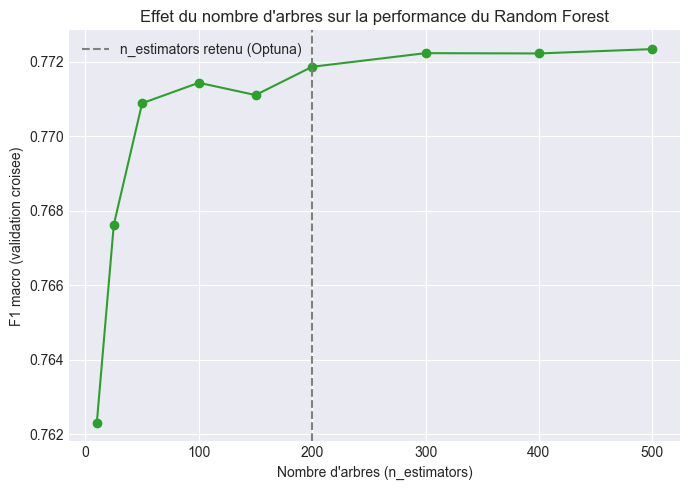

In [16]:
'''
Calcule le score F1 macro en validation croisee pour differentes valeurs de n_estimators,
toutes choses egales par ailleurs (les autres hyperparametres sont fixes a leur valeur
optimale trouvee par Optuna). Permet de visualiser le plateau de performance attendu par
la loi des grands nombres (cours, chapitre 9).
'''
n_estimators_range = np.array([10, 25, 50, 100, 150, 200, 300, 400, 500])

rf_params_fixed = {k: v for k, v in rf_best_params.items() if k != "n_estimators"}

scores_n_estimators = []
for n_est in n_estimators_range:
    pipeline = make_model_pipeline(
        RandomForestClassifier(
            n_estimators=n_est,
            **rf_params_fixed,
            class_weight=RF_CLASS_WEIGHT,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    )
    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv5, scoring="f1_macro", n_jobs=-1, error_score=0.0
    )
    scores_n_estimators.append(scores.mean())
    print(f"n_estimators={n_est:<4} f1_macro={scores.mean():.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(n_estimators_range, scores_n_estimators, "o-", color="#2ca02c")
ax.axvline(rf_best_params["n_estimators"], linestyle="--", color="gray",
           label="n_estimators retenu (Optuna)")
ax.set_xlabel("Nombre d'arbres (n_estimators)")
ax.set_ylabel("F1 macro (validation croisee)")
ax.set_title("Effet du nombre d'arbres sur la performance du Random Forest")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

On remarque que le score grimpe tres vite jusqu'a 50-100 arbres, puis atteint un plateau quasi
parfait a partir de la (autour de 0,77). Le n_estimators retenu par Optuna (200) se situe deja
en plein milieu de ce plateau, donc on aurait probablement pu s'en tenir a moins d'arbres sans
perdre en performance. Ça illustre bien la loi des grands nombres du cours : au-dela d'un
certain nombre de "votants", ajouter encore plus d'arbres n'apporte plus grand-chose.

## 8. Comparaison Arbre de decision vs Random Forest

Comparaison directe des deux modeles sur le test set, pour quantifier l'apport du bagging
par rapport a l'arbre seul (cf. cours : reduction de variance, frontiere de decision moins
irreguliere).

In [17]:
'''
Calcule, pour les 2 modeles entraines, les metriques de reference sur le test set :
accuracy, balanced accuracy et F1 macro.
'''
comparison_rows = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    comparison_rows.append({
        "Modele":            name,
        "Accuracy":          accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "F1 macro":          f1_score(y_test, y_pred, average="macro"),
    })

df_comparison = pd.DataFrame(comparison_rows).sort_values("F1 macro", ascending=False)
df_comparison = df_comparison.reset_index(drop=True)
print(df_comparison.to_string(index=False))

BEST_MODEL_NAME = df_comparison.loc[0, "Modele"]
best_model = trained_models[BEST_MODEL_NAME]
print(f"\nModele retenu pour l'analyse detaillee : {BEST_MODEL_NAME}")


           Modele  Accuracy  Balanced Accuracy  F1 macro
    Random Forest  0.828094           0.830978  0.787601
Arbre de decision  0.832882           0.765349  0.765794

Modele retenu pour l'analyse detaillee : Random Forest


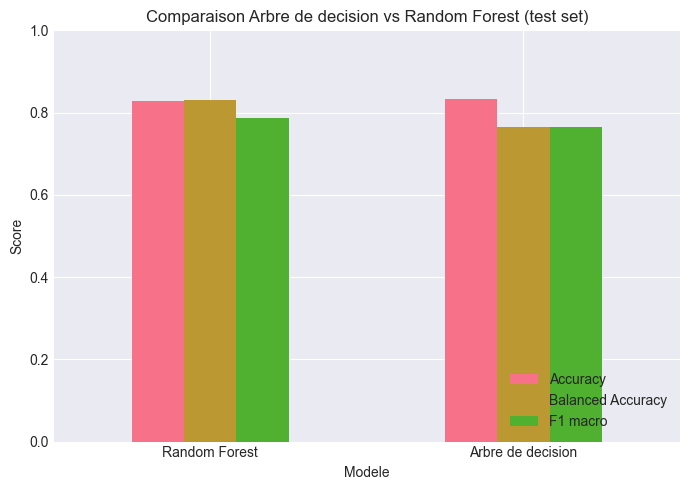

In [18]:
'''
Visualisation comparative des 2 modeles sur les 3 metriques de reference.
'''
fig, ax = plt.subplots(figsize=(7, 5))
df_plot = df_comparison.set_index("Modele")
df_plot.plot(kind="bar", ax=ax)
ax.set_title("Comparaison Arbre de decision vs Random Forest (test set)")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

Le Random Forest l'emporte nettement sur le F1 macro (0,788 contre 0,766 pour l'arbre seul),
alors que les deux modeles ont une accuracy quasiment identique (0,828 vs 0,833). L'ecart vient
surtout de la Balanced Accuracy, bien meilleure pour la foret (0,831 contre 0,765) : le Random
Forest est nettement plus equilibre entre les trois classes, alors que l'arbre seul reste plus
performant sur la classe majoritaire mais moins bon sur les classes minoritaires.

## 9. Evaluation des modeles


### 9.1 Courbes d'apprentissage (train vs validation)

La courbe d'apprentissage montre l'evolution du score (F1 macro) sur le train set et sur le
validation set en fonction de la quantite de donnees d'entrainement utilisee, pour les 2
modeles. On s'attend, d'apres le cours, a observer un ecart train/validation plus marque pour
l'arbre seul que pour le Random Forest (variance plus elevee).

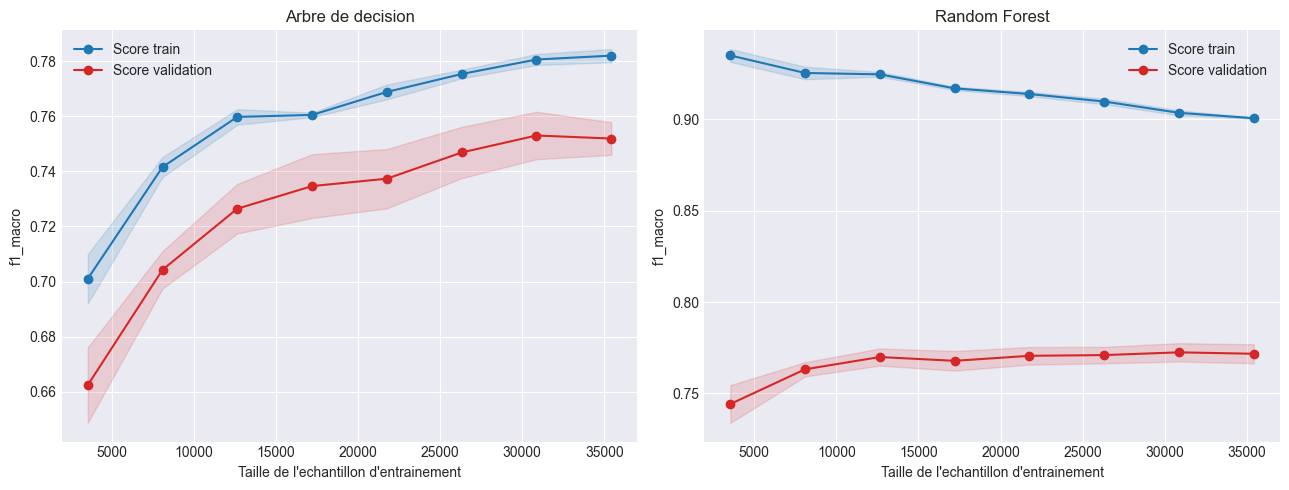

In [19]:
def plot_learning_curve(model, X, y, title, ax, cv=cv5, scoring="f1_macro"):
    '''
    Calcule et trace la courbe d'apprentissage d'un modele deja configure (pipeline
    complet avec son estimateur final), en utilisant la fonction learning_curve de
    scikit-learn. Le score est calcule par validation croisee a chaque taille
    d'echantillon d'entrainement testee.
    '''
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=cv, scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1, random_state=RANDOM_STATE,
    )

    train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, "o-", label="Score train", color="#1f77b4")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                     alpha=0.15, color="#1f77b4")
    ax.plot(train_sizes, val_mean, "o-", label="Score validation", color="#d62728")
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                     alpha=0.15, color="#d62728")

    ax.set_title(title)
    ax.set_xlabel("Taille de l'echantillon d'entrainement")
    ax.set_ylabel(scoring)
    ax.legend(loc="best")


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, model) in zip(axes, trained_models.items()):
    plot_learning_curve(model, X_train, y_train, name, ax)
plt.tight_layout()
plt.show()


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

L'ecart train-validation est beaucoup plus
large pour le Random Forest (train ~0,90-0,93, validation ~0,75-0,77) que pour l'arbre seul
(train ~0,70-0,78, validation ~0,66-0,75). On s'attendrait plutot a l'inverse d'apres le cours,
puisque le bagging est cense reduire la variance par rapport a un arbre unique. Ici, le Random
Forest reste quand meme meilleur en valeur absolue sur le validation set, mais il sur-apprend
visiblement plus que l'arbre seul sur ce jeu de donnees.

### 9.2 Diagnostic de surapprentissage (accuracy)

Complement a la courbe d'apprentissage ci-dessus, base sur l'accuracy (et non le F1 macro),
pour les 2 modeles sur le meme graphique. Un seuil de surapprentissage est fixe arbitrairement
a 0.10 : au-dela de cet ecart entre le score train et le score validation, on considere que
le modele apprend trop specifiquement les donnees d'entrainement.

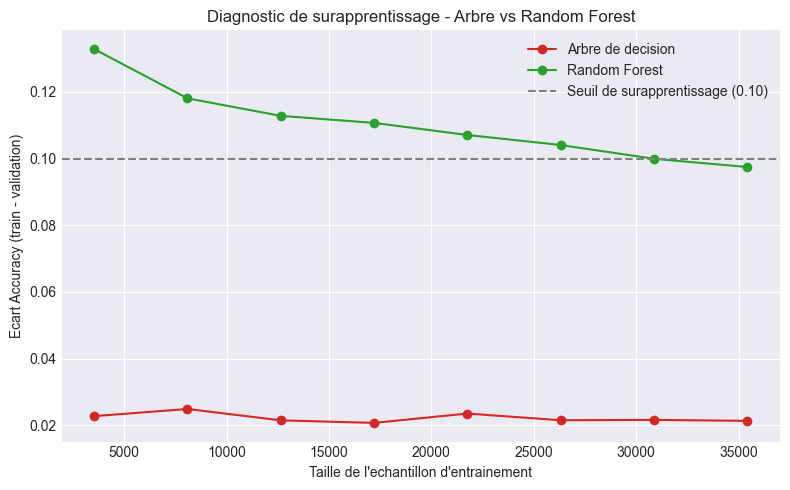

In [20]:
'''
Diagnostic de surapprentissage des 2 modeles, base sur l'accuracy. Reutilise la fonction
learning_curve (comme pour la courbe d'apprentissage ci-dessus), mais avec l'accuracy comme
metrique de suivi plutot que le F1 macro, pour comparer leur comportement sur un meme
graphique.
'''
SEUIL_OVERFITTING = 0.10

couleurs_modeles = {
    "Arbre de decision": "#d62728",
    "Random Forest":     "#2ca02c",
}

fig, ax = plt.subplots(figsize=(8, 5))

for name, model in trained_models.items():
    train_sizes_acc, train_scores_acc, val_scores_acc = learning_curve(
        model, X_train, y_train,
        cv=cv5, scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1, random_state=RANDOM_STATE,
    )
    ecart_train_val_acc = train_scores_acc.mean(axis=1) - val_scores_acc.mean(axis=1)
    couleur = couleurs_modeles.get(name, None)
    ax.plot(train_sizes_acc, ecart_train_val_acc, "o-", color=couleur, label=name)

ax.axhline(SEUIL_OVERFITTING, linestyle="--", color="gray",
           label=f"Seuil de surapprentissage ({SEUIL_OVERFITTING:.2f})")

ax.set_xlabel("Taille de l'echantillon d'entrainement")
ax.set_ylabel("Ecart Accuracy (train - validation)")
ax.set_title("Diagnostic de surapprentissage - Arbre vs Random Forest")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

Ça confirme ce qu'on vient de voir : l'ecart train-validation de l'arbre seul reste tres stable
et faible (autour de 0,02, donc largement sous le seuil de 0,10), alors que le Random Forest
part de 0,13 et ne redescend qu'a 0,10 pour le plus grand echantillon teste. Donc sur ce
probleme precis, c'est le Random Forest qui sur-apprend le plus, pas l'arbre seul — probablement
du aux hyperparametres retenus par Optuna (max_depth=27, min_samples_leaf=2 seulement, donc des
arbres individuels tres profonds et peu contraints au sein de la foret).

### 9.3 Matrice de confusion

Une ligne par modele, pour comparer directement leurs erreurs de classement.

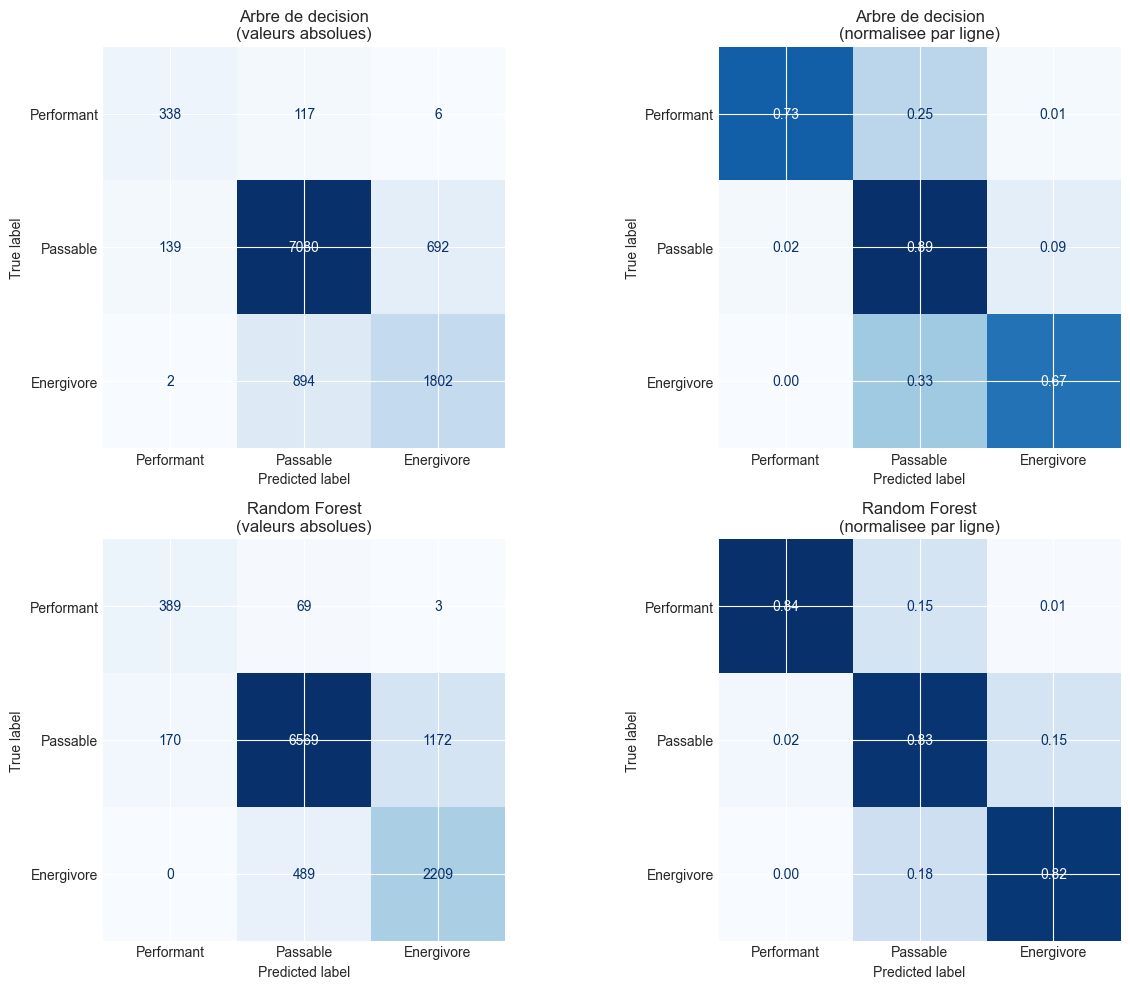

In [21]:
'''
Matrice de confusion des 2 modeles sur le test set, en valeurs absolues et normalisee
par ligne (taux de rappel par classe).
'''
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for row, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred, labels=GROUPS)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=GROUPS)
    disp.plot(ax=axes[row, 0], cmap="Blues", colorbar=False)
    axes[row, 0].set_title(f"{name}\n(valeurs absolues)")

    cm_norm = confusion_matrix(y_test, y_pred, labels=GROUPS, normalize="true")
    disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=GROUPS)
    disp_norm.plot(ax=axes[row, 1], cmap="Blues", colorbar=False, values_format=".2f")
    axes[row, 1].set_title(f"{name}\n(normalisee par ligne)")

plt.tight_layout()
plt.show()


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

Le Random Forest ameliore nettement le rappel des deux classes minoritaires par rapport a
l'arbre seul : Performant passe de 73 % a 84 % de rappel, et Energivore de 67 % a 82 %. Comme
pour les notebooks precedents, on remarque qu'il n'y a quasiment aucune confusion directe entre
Performant et Energivore, les erreurs passant systematiquement par Passable.

### 9.4 Rapport de classification (precision / rappel / F1 par classe)

Rapport detaille pour les 2 modeles.

In [22]:
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    print(f"Rapport de classification - {name}\n")
    print(classification_report(y_test, y_pred, target_names=GROUPS, digits=3))
    print()


Rapport de classification - Arbre de decision

              precision    recall  f1-score   support

  Performant      0.721     0.668     0.693      2698
    Passable      0.875     0.895     0.885      7911
  Energivore      0.706     0.733     0.719       461

    accuracy                          0.833     11070
   macro avg      0.767     0.765     0.766     11070
weighted avg      0.830     0.833     0.831     11070


Rapport de classification - Random Forest

              precision    recall  f1-score   support

  Performant      0.653     0.819     0.726      2698
    Passable      0.922     0.830     0.874      7911
  Energivore      0.696     0.844     0.763       461

    accuracy                          0.828     11070
   macro avg      0.757     0.831     0.788     11070
weighted avg      0.847     0.828     0.833     11070




#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

Le Random Forest ameliore le F1 sur Performant (0,726 contre 0,693) et sur Energivore (0,763
contre 0,719), au prix d'une legere baisse de precision sur Performant (0,653 contre 0,721).
L'arbre seul reste un peu meilleur sur Passable (F1 0,885 contre 0,874). Globalement, le Random
Forest est plus equilibre entre les trois classes, ce qui est coherent avec son meilleur F1
macro global.

### 9.5 Courbes ROC et Precision-Rappel (one-vs-rest)

Une ligne par modele. La courbe ROC peut se montrer trop optimiste lorsque les classes sont
fortement desequilibrees (cas ici), la courbe precision-rappel est donc affichee en
complement.

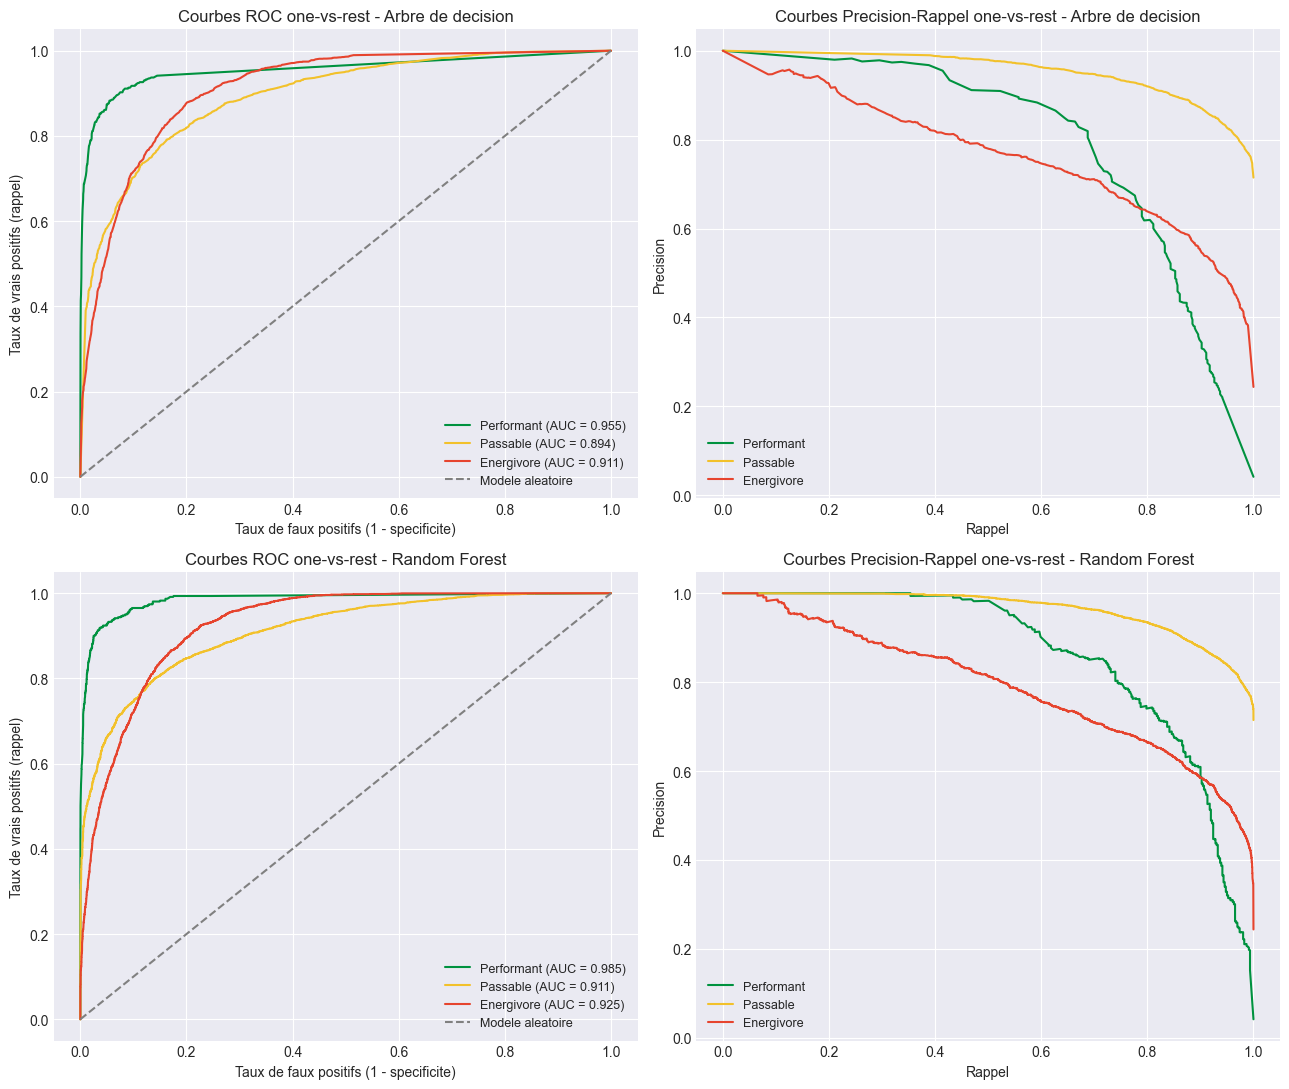

In [26]:
'''
Calcule les courbes ROC et Precision-Rappel pour chaque classe en one-vs-rest, pour les
2 modeles. Une ligne par modele. Les colonnes de predict_proba sont reordonnees selon l'ordre
de GROUPS, car scikit-learn trie les classes alphabetiquement (model.classes_), ce qui ne
correspond pas a l'ordre attendu pour label_binarize.
'''
y_test_bin = label_binarize(y_test, classes=GROUPS)

fig, axes = plt.subplots(2, 2, figsize=(13, 11))

for row, (name, model) in enumerate(trained_models.items()):
    y_proba_raw = model.predict_proba(X_test)
    class_order = list(model.classes_)
    reorder_idx = [class_order.index(grp) for grp in GROUPS]
    y_proba = y_proba_raw[:, reorder_idx]

    for i, grp in enumerate(GROUPS):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        axes[row, 0].plot(fpr, tpr, color=GROUP_COLORS[grp],
                           label=f"{grp} (AUC = {roc_auc:.3f})")
    axes[row, 0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Modele aleatoire")
    axes[row, 0].set_xlabel("Taux de faux positifs (1 - specificite)")
    axes[row, 0].set_ylabel("Taux de vrais positifs (rappel)")
    axes[row, 0].set_title(f"Courbes ROC one-vs-rest - {name}")
    axes[row, 0].legend(loc="lower right", fontsize=9)

    for i, grp in enumerate(GROUPS):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
        axes[row, 1].plot(recall, precision, color=GROUP_COLORS[grp], label=grp)
    axes[row, 1].set_xlabel("Rappel")
    axes[row, 1].set_ylabel("Precision")
    axes[row, 1].set_title(f"Courbes Precision-Rappel one-vs-rest - {name}")
    axes[row, 1].legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.show()

#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

Le Random Forest ameliore l'AUC sur les trois classes par rapport a l'arbre seul, et l'ecart le
plus marque concerne Performant (0,985 contre 0,955). Comme dans les autres notebooks, Passable
reste la classe la plus stable sur la courbe Precision-Rappel, alors que Performant et
Energivore voient leur precision chuter assez vite a partir d'un rappel de 0,6-0,7.

## 10. Diagnostics propres aux arbres

### 10.1 Importance des variables (Gini)

Une variable importante reduit davantage l'impurete de Gini lorsqu'elle est utilisee pour
decouper un noeud (cf. cours, chapitre 9). Cette mesure est disponible nativement pour les
2 modeles (`feature_importances_`), et permet de verifier si l'arbre seul et le Random Forest
s'accordent sur les variables les plus determinantes.

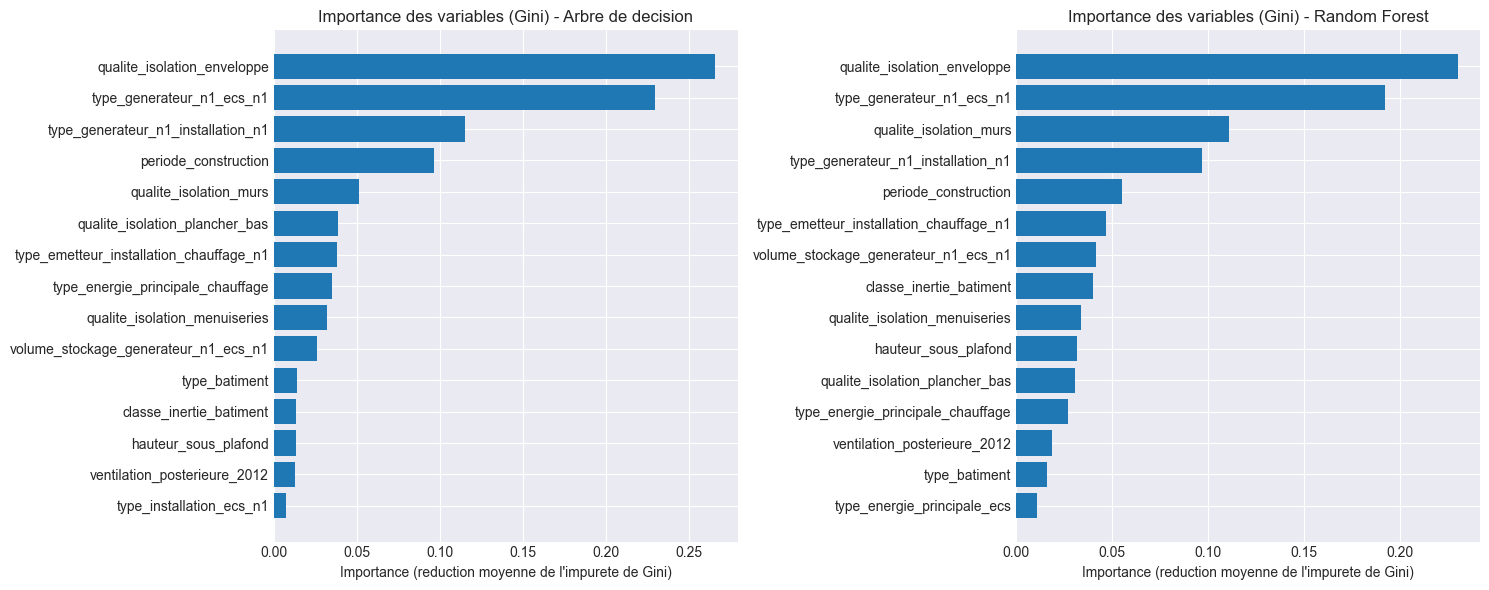

In [24]:
'''
Affiche les 15 variables les plus importantes pour chacun des 2 modeles, mesurees par la
reduction moyenne de l'impurete de Gini qu'elles apportent.
'''
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (name, model) in zip(axes, trained_models.items()):
    feature_names = model.named_steps["pre"].get_feature_names_out()
    importances = model.named_steps["clf"].feature_importances_

    importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

    ax.barh(importance_df.index[::-1], importance_df.values[::-1], color="#1f77b4")
    ax.set_title(f"Importance des variables (Gini) - {name}")
    ax.set_xlabel("Importance (reduction moyenne de l'impurete de Gini)")

plt.tight_layout()
plt.show()


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

Les deux modeles s'accordent bien sur les variables les plus importantes :
`qualite_isolation_enveloppe` et `type_generateur_n1_ecs_n1` arrivent en tete dans les deux cas,
ce qui rejoint le premier split observe dans l'arbre (section 6.3). On remarque que le Random
Forest repartit un peu plus l'importance sur davantage de variables (la distribution est moins
concentree sur les deux premieres que pour l'arbre seul), ce qui est coherent avec le tirage
aleatoire de variables a chaque noeud propre au Random Forest.

### 10.2 Courbe de validation sur la profondeur (max_depth)

Fait varier uniquement la profondeur maximale, toutes choses egales par ailleurs, pour les
2 modeles, et trace le score sur le train set et sur le validation set pour chaque valeur
testee. Permet de visualiser independamment le compromis biais/variance associe a cet
hyperparametre, et de voir si l'arbre seul atteint son point de sur-apprentissage plus tot
que le Random Forest.

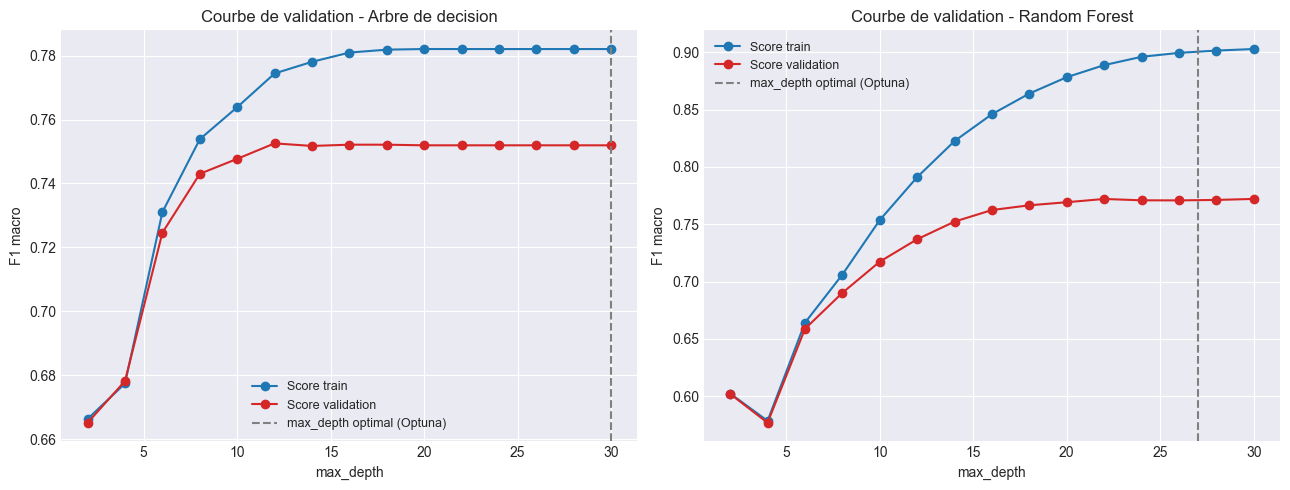

In [25]:
'''
Trace la courbe de validation sur max_depth pour les 2 modeles, a partir de leurs autres
hyperparametres optimaux respectifs (trouves par Optuna).
'''
depth_range = np.arange(2, 31, 2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Arbre de decision
tree_params_fixed = {k: v for k, v in tree_best_params.items() if k != "max_depth"}
pipeline_tree = make_model_pipeline(
    DecisionTreeClassifier(**tree_params_fixed, class_weight=TREE_CLASS_WEIGHT, random_state=RANDOM_STATE)
)
train_scores_tree, val_scores_tree = validation_curve(
    pipeline_tree, X_train, y_train,
    param_name="clf__max_depth", param_range=depth_range,
    cv=cv5, scoring="f1_macro", n_jobs=-1
)
axes[0].plot(depth_range, train_scores_tree.mean(axis=1), "o-", label="Score train", color="#1f77b4")
axes[0].plot(depth_range, val_scores_tree.mean(axis=1), "o-", label="Score validation", color="#d62728")
axes[0].axvline(tree_best_params["max_depth"], linestyle="--", color="gray", label="max_depth optimal (Optuna)")
axes[0].set_xlabel("max_depth")
axes[0].set_ylabel("F1 macro")
axes[0].set_title("Courbe de validation - Arbre de decision")
axes[0].legend(loc="best", fontsize=9)

# Random Forest
rf_params_fixed_depth = {k: v for k, v in rf_best_params.items() if k != "max_depth"}
pipeline_rf = make_model_pipeline(
    RandomForestClassifier(**rf_params_fixed_depth, class_weight=RF_CLASS_WEIGHT,
                            random_state=RANDOM_STATE, n_jobs=-1)
)
train_scores_rf, val_scores_rf = validation_curve(
    pipeline_rf, X_train, y_train,
    param_name="clf__max_depth", param_range=depth_range,
    cv=cv5, scoring="f1_macro", n_jobs=-1
)
axes[1].plot(depth_range, train_scores_rf.mean(axis=1), "o-", label="Score train", color="#1f77b4")
axes[1].plot(depth_range, val_scores_rf.mean(axis=1), "o-", label="Score validation", color="#d62728")
axes[1].axvline(rf_best_params["max_depth"], linestyle="--", color="gray", label="max_depth optimal (Optuna)")
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("F1 macro")
axes[1].set_title("Courbe de validation - Random Forest")
axes[1].legend(loc="best", fontsize=9)

plt.tight_layout()
plt.show()


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

Pour l'arbre seul, le score validation plafonne tres vite (vers max_depth=12) et reste stable
ensuite, avec un ecart train-validation qui ne se creuse quasiment pas. Pour le Random Forest,
l'ecart commence a se creuser nettement a partir de max_depth=14-16 et continue de grandir
legerement jusqu'a la valeur retenue par Optuna (27). Ça confirme encore une fois que c'est la
profondeur des arbres individuels qui explique le sur-apprentissage plus marque du Random
Forest sur ce probleme.

**Interpretation a completer.**

## 11. Conclusion

On a comparé un arbre de decision seul et un Random Forest sur le meme problème de
classification du DPE. C'est le **Random Forest** qui se demarque comme le meilleur modele,
avec un F1 macro de 0,788 sur le test set, contre 0,766 pour l'arbre seul. L'ecart vient surtout
de la Balanced Accuracy (0,831 contre 0,765), donc la foret est nettement plus equilibree entre
les trois classes.

Par contre, on remarque un resultat assez contre-intuitif par rapport au cours : c'est le Random
Forest qui sur-apprend le plus, pas l'arbre seul. L'arbre garde un ecart train-validation tres
stable et faible (autour de 0,02), alors que le Random Forest part de 0,13 et ne redescend qu'a
0,10 avec le maximum de donnees disponibles. Ça vient probablement des hyperparametres retenus
par Optuna (arbres tres profonds, peu contraints), plutot que d'une limite du bagging en
lui-meme.

Le score OOB (0,8206) reste tres coherent avec le score de validation croisee et le score test,
ce qui confirme que cette estimation est fiable sur ce modèle.

Les deux modeles s'accordent bien sur les variables les plus importantes,
`qualite_isolation_enveloppe` et `type_generateur_n1_ecs_n1` arrivant en tête dans les deux cas.

Par rapport aux notebooks precedents, le Random Forest est clairement le meilleur des trois
modèles testes jusqu'ici (F1 macro 0,788 contre 0,726 pour Elastic Net et 0,727 pour le SVM),
avec en plus l'avantage d'etre rapide a entrainer, contrairement au SVM qui a demande de
sous-echantillonner.

Comme limites, on peut citer l'absence de calibration des probabilites, et le sur-apprentissage
plus marque du Random Forest qui pourrait etre reduit en contraignant un peu plus les
hyperparametres (max_depth, min_samples_leaf) dans une iteration future.